In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
import xgboost as xgb
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')


In [2]:
data=(r"C:\Users\Sarika\Downloads\Astram_events.csv")
df=pd.read_csv(data)
print(df.info())
print(f'Event types: {df["event_type"].value_counts().to_dict()}')
print(f'Date range: {df["start_datetime"].dropna().min()[:10]} -{df["start_datetime"].dropna().max()[:10]}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   object 
 1   event_type             8173 non-null   object 
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   object 
 7   end_address            687 non-null    object 
 8   event_cause            8173 non-null   object 
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   object 
 11  end_datetime           490 non-null    object 
 12  status                 8173 non-null   object 
 13  authenticated          8173 non-null   object 
 14  modified_datetime      8173 non-null   object 
 15  map_

In [3]:
#Datetime parsing
for col in ['start_datetime', 'end_datetime', 'closed_datetime']:
    df[col.replace('datetime', 'dt')] = pd.to_datetime(df[col], errors='coerce', utc=True)

df['duration_hrs'] = (df['end_dt'] - df['start_dt']).dt.total_seconds() / 3600
df.loc[df['duration_hrs'].isna(), 'duration_hrs'] = (
    df['closed_dt'] - df['start_dt']).dt.total_seconds() / 3600
df['duration_hrs'] = df['duration_hrs'].clip(0, 72)
df['hour']        = df['start_dt'].dt.hour
df['day_of_week'] = df['start_dt'].dt.day_name()
df['month']       = df['start_dt'].dt.month

# Impact scoring
CAUSE_SEVERITY = {
    'accident': 5, 'congestion': 5, 'public_event': 4, 'procession': 4,
    'protest': 4,  'vip_movement': 3, 'construction': 3, 'water_logging': 3,
    'vehicle_breakdown': 2, 'tree_fall': 2, 'road_conditions': 2,
    'pot_holes': 1, 'Debris': 2, 'others': 1, 'test_demo': 0
}
df['severity_score']  = df['event_cause'].map(CAUSE_SEVERITY).fillna(1)
df['priority_score']  = df['priority'].map({'High': 2, 'Low': 1}).fillna(1)
df['closure_score']   = df['requires_road_closure'].map({'TRUE': 2, 'FALSE': 1}).fillna(1)
df['impact_score']    = df['severity_score'] * df['priority_score'] * df['closure_score']

# Haversine distance 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

print('Feature engineering done')
print(f'Impact score range: {df["impact_score"].min():.0f} – {df["impact_score"].max():.0f}')
print(f'Missing lat/lon: {df[["latitude","longitude"]].isnull().sum().sum()}')

Feature engineering done
Impact score range: 0 – 10
Missing lat/lon: 0


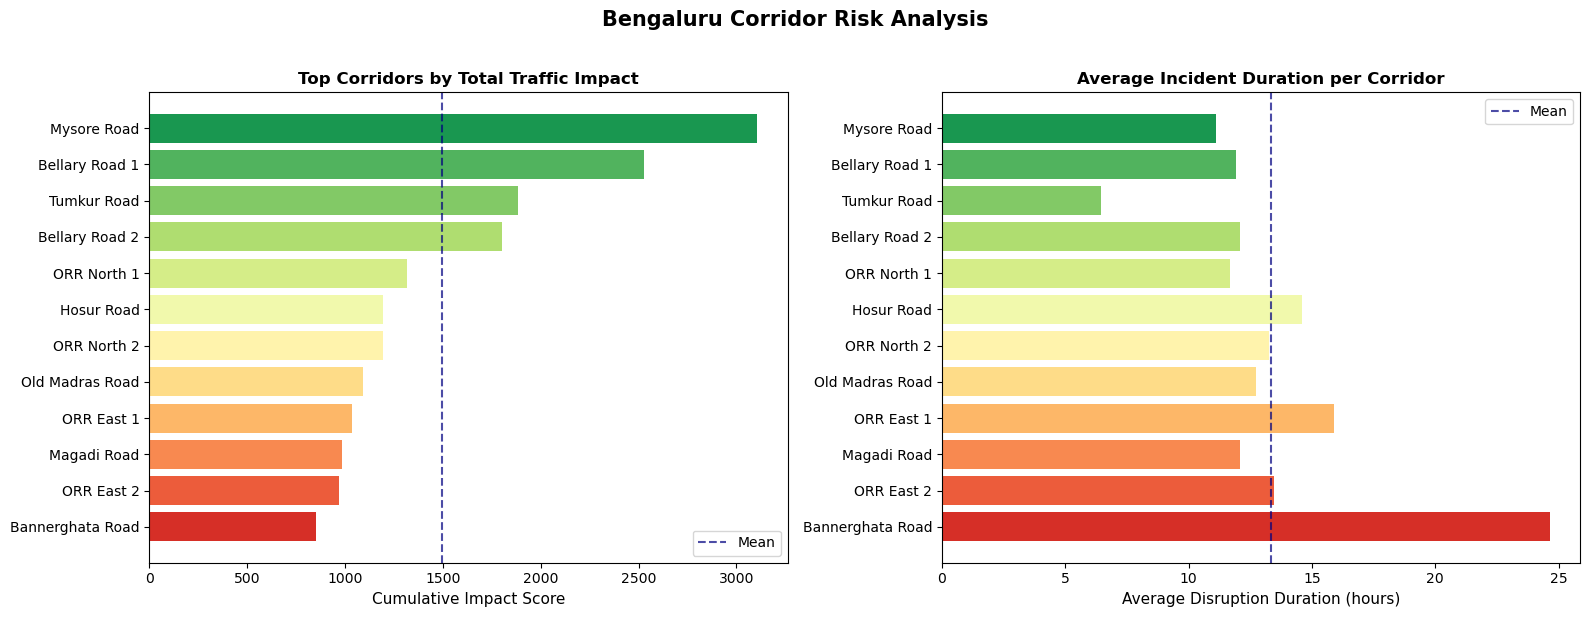


Top 5 highest-risk corridors:
      corridor  total_incidents  total_impact  avg_duration_hrs  road_closures
   Mysore Road              743        3106.0         11.108386              0
Bellary Road 1              610        2528.0         11.916723              0
   Tumkur Road              458        1886.0          6.457604              0
Bellary Road 2              379        1804.0         12.086605              0
   ORR North 1              275        1318.0         11.679076              0


In [4]:
corridor_risk = (
    df[df['corridor'].notna() & (df['corridor'] != 'NULL')]
    .groupby('corridor')
    .agg(
        total_incidents   = ('id', 'count'),
        avg_impact        = ('impact_score', 'mean'),
        total_impact      = ('impact_score', 'sum'),
        avg_duration_hrs  = ('duration_hrs', 'mean'),
        road_closures     = ('requires_road_closure', lambda x: (x == 'TRUE').sum()),
        high_priority     = ('priority', lambda x: (x == 'High').sum())
    )
    .reset_index()
    .sort_values('total_impact', ascending=False)
)

named_corridors = corridor_risk[corridor_risk['corridor'] != 'Non-corridor'].head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bengaluru Corridor Risk Analysis', fontsize=15, fontweight='bold', y=1.02)

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(named_corridors)))

# Total impact
axes[0].barh(named_corridors['corridor'][::-1], named_corridors['total_impact'][::-1], color=colors[::-1])
axes[0].set_xlabel('Cumulative Impact Score', fontsize=11)
axes[0].set_title('Top Corridors by Total Traffic Impact', fontweight='bold')
axes[0].axvline(named_corridors['total_impact'].mean(), color='navy', linestyle='--', alpha=0.7, label='Mean')
axes[0].legend()

# Avg duration
axes[1].barh(named_corridors['corridor'][::-1], named_corridors['avg_duration_hrs'][::-1], color=colors[::-1])
axes[1].set_xlabel('Average Disruption Duration (hours)', fontsize=11)
axes[1].set_title('Average Incident Duration per Corridor', fontweight='bold')
axes[1].axvline(named_corridors['avg_duration_hrs'].mean(), color='navy', linestyle='--', alpha=0.7, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('corridor_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop 5 highest-risk corridors:')
print(named_corridors[['corridor','total_incidents','total_impact','avg_duration_hrs','road_closures']].head(5).to_string(index=False))

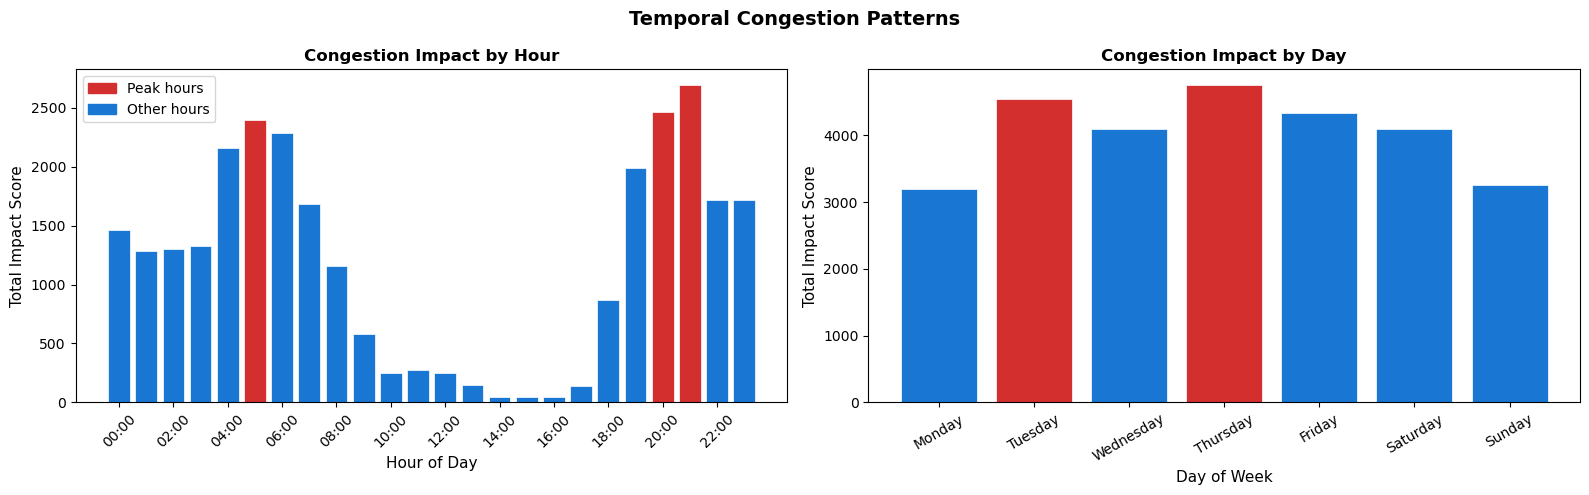

Peak congestion hours: [21, 20, 5]
Highest risk days: ['Thursday', 'Tuesday']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Temporal Congestion Patterns', fontsize=14, fontweight='bold')

# Hourly
hourly = df.groupby('hour')['impact_score'].sum().reindex(range(24), fill_value=0)
peak_hours = hourly.nlargest(3).index.tolist()
bar_colors = ['#d32f2f' if h in peak_hours else '#1976d2' for h in range(24)]
axes[0].bar(range(24), hourly.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Hour of Day', fontsize=11)
axes[0].set_ylabel('Total Impact Score', fontsize=11)
axes[0].set_title('Congestion Impact by Hour', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
red_patch = mpatches.Patch(color='#d32f2f', label='Peak hours')
blue_patch = mpatches.Patch(color='#1976d2', label='Other hours')
axes[0].legend(handles=[red_patch, blue_patch])

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['impact_score'].sum().reindex(day_order, fill_value=0)
day_colors = ['#d32f2f' if d in daily.nlargest(2).index else '#1976d2' for d in day_order]
axes[1].bar(day_order, daily.values, color=day_colors, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Total Impact Score', fontsize=11)
axes[1].set_title('Congestion Impact by Day', fontweight='bold')
axes[1].set_xticklabels(day_order, rotation=30)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak congestion hours: {peak_hours}')
print(f'Highest risk days: {daily.nlargest(2).index.tolist()}')

In [29]:
planned   = df[(df['event_type'] == 'planned') &
               df['latitude'].notna() & df['longitude'].notna() &
               df['start_dt'].notna()].copy()
unplanned = df[(df['event_type'] == 'unplanned') &
               df['latitude'].notna() & df['longitude'].notna() &
               df['start_dt'].notna()].copy()

print(f'Computing spatial-temporal impact for {len(planned)} planned events')

results = []
for _, ev in planned.iterrows():
    # 6-hour window
    window = unplanned[
        (unplanned['start_dt'] >= ev['start_dt']) &
        (unplanned['start_dt'] <= ev['start_dt'] + pd.Timedelta(hours=6))
    ].copy()

    if len(window) > 0:
        window['dist_km'] = window.apply(
            lambda r: haversine(ev['latitude'], ev['longitude'],
                                r['latitude'], r['longitude']), axis=1)
        nearby = window[window['dist_km'] <= 5]
    else:
        nearby = window

    results.append({
        'event_id'         : ev['id'],
        'event_cause'      : ev['event_cause'],
        'corridor'         : ev['corridor'],
        'hour'             : ev['hour'],
        'day_of_week'      : ev['day_of_week'],
        'requires_closure' : ev['requires_road_closure'],
        'priority'         : ev['priority'],
        'nearby_incidents' : len(nearby),
        'total_impact'     : nearby['impact_score'].sum() if len(nearby) > 0 else 0,
        'avg_dist_km'      : nearby['dist_km'].mean() if len(nearby) > 0 else 0,
        'has_accident'     : int((nearby['event_cause'] == 'accident').any()) if len(nearby) > 0 else 0
    })

impact_df = pd.DataFrame(results)
# Outlier detection 
Q1 = impact_df['total_impact'].quantile(0.25)
Q3 = impact_df['total_impact'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
outliers = impact_df[impact_df['total_impact'] > upper_bound]
print(f"Extreme impact outliers: {len(outliers)}")
impact_df = impact_df[impact_df['total_impact'] <= upper_bound]
print(f"Rows after outlier removal: {len(impact_df)}")

# Impact category
impact_df['impact_category'] = pd.cut(
    impact_df['total_impact'],
    bins=[-1, 0, 5, 15, float('inf')],
    labels=['None', 'Low', 'Medium', 'High']
)
print("Impact category distribution:")
print(impact_df['impact_category'].value_counts())

print('Impact distribution across planned events:')
print(impact_df['impact_category'].value_counts())
print(f'\nAverage nearby incidents per event: {impact_df["nearby_incidents"].mean():.1f}')
print(f'Max nearby incidents (single event): {impact_df["nearby_incidents"].max()}')

Computing spatial-temporal impact for 365 planned events
Extreme impact outliers: 5
Rows after outlier removal: 360
Impact category distribution:
impact_category
None      117
Medium     97
Low        93
High       53
Name: count, dtype: int64
Impact distribution across planned events:
impact_category
None      117
Medium     97
Low        93
High       53
Name: count, dtype: int64

Average nearby incidents per event: 1.9
Max nearby incidents (single event): 12


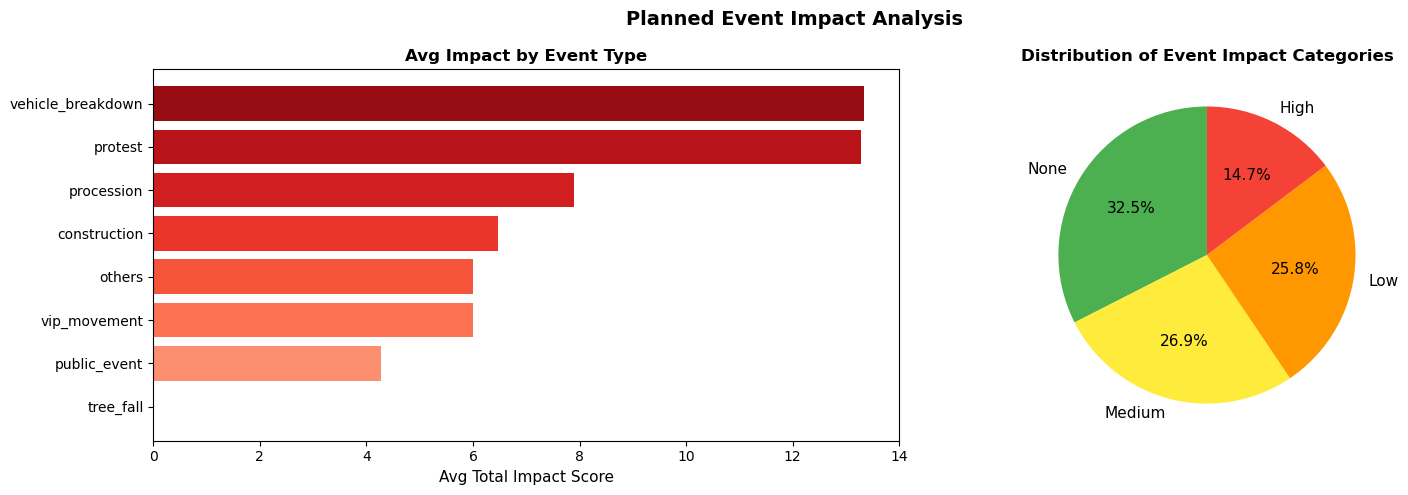

In [7]:
# Impact by event cause 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Planned Event Impact Analysis', fontsize=14, fontweight='bold')

cause_impact = impact_df.groupby('event_cause')[['nearby_incidents','total_impact']].mean().sort_values('total_impact', ascending=False)
cause_colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(cause_impact)))

axes[0].barh(cause_impact.index[::-1], cause_impact['total_impact'][::-1], color=cause_colors)
axes[0].set_xlabel('Avg Total Impact Score', fontsize=11)
axes[0].set_title('Avg Impact by Event Type', fontweight='bold')

# Category distribution 
cat_counts = impact_df['impact_category'].value_counts()
pie_colors = ['#4caf50','#ffeb3b','#ff9800','#f44336']
axes[1].pie(cat_counts.values, labels=cat_counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribution of Event Impact Categories', fontweight='bold')

plt.tight_layout()
plt.savefig('event_impact.png', dpi=150, bbox_inches='tight')
plt.show()

XGBoost CV F1: 0.364 ± 0.023

-- XGBoost Classification Report --
              precision    recall  f1-score   support

        High       0.60      0.55      0.57        11
         Low       0.21      0.16      0.18        19
      Medium       0.39      0.37      0.38        19
        None       0.47      0.61      0.53        23

    accuracy                           0.42        72
   macro avg       0.42      0.42      0.41        72
weighted avg       0.40      0.42      0.40        72

Feature Importances:
hour            0.131
duration_hrs    0.126
corridor_enc    0.117
cause_enc       0.114
is_peak_hour    0.113
day_enc         0.102
priority_enc    0.101
closure_enc     0.099
is_weekend      0.097
dtype: float32


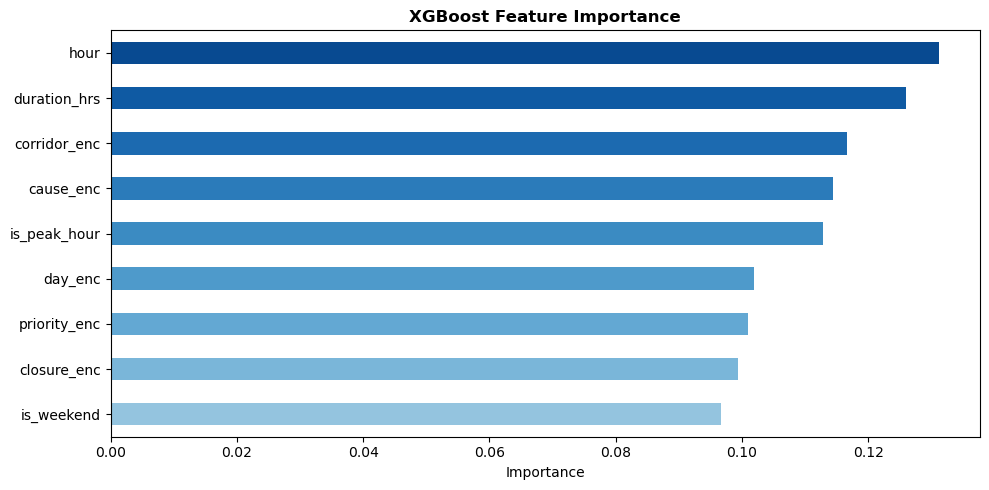

In [8]:

if 'duration_hrs' in impact_df.columns:
    impact_df = impact_df.drop(columns=['duration_hrs'])

# Merge additional columns from main df 
extra_cols = df[['id', 'duration_hrs', 'zone', 'month', 'junction']].rename(
    columns={'id': 'event_id'}
)
impact_df_model = impact_df.merge(extra_cols, on='event_id', how='left')

extra_cols = df[['id', 'duration_hrs', 'zone', 'month', 'junction']].rename(
    columns={'id': 'event_id'}
)
impact_df_model = impact_df.merge(extra_cols, on='event_id', how='left')

# Feature 
model_df = impact_df_model.copy()

le_cause    = LabelEncoder()
le_corridor = LabelEncoder()
le_day      = LabelEncoder()
le_priority = LabelEncoder()
le_closure  = LabelEncoder()
le_zone     = LabelEncoder()
le_junction = LabelEncoder()

model_df['cause_enc']    = le_cause.fit_transform(model_df['event_cause'].fillna('unknown'))
model_df['corridor_enc'] = le_corridor.fit_transform(model_df['corridor'].fillna('unknown'))
model_df['day_enc']      = le_day.fit_transform(model_df['day_of_week'].fillna('unknown'))
model_df['priority_enc'] = le_priority.fit_transform(model_df['priority'].fillna('Low'))
model_df['closure_enc']  = le_closure.fit_transform(model_df['requires_closure'].fillna('FALSE'))
model_df['junction_enc'] = le_junction.fit_transform(model_df['junction'].fillna('unknown'))

model_df['duration_hrs'] = model_df['duration_hrs'].fillna(model_df['duration_hrs'].median())
model_df['month']        = model_df['month'].fillna(model_df['month'].median())

PEAK_HOURS = [19, 20, 21]
model_df['is_peak_hour'] = model_df['hour'].isin(PEAK_HOURS).astype(int)
model_df['is_weekend']   = model_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

FEATURES = ['cause_enc', 'corridor_enc', 'hour', 'day_enc', 'priority_enc',
            'closure_enc', 'is_peak_hour', 'is_weekend', 'duration_hrs']

X = model_df[FEATURES]
y = model_df['impact_category'].astype(str)

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# model 
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb_scores = cross_val_score(xgb_model, X, y_encoded, cv=cv, scoring='f1_weighted')
print(f"XGBoost CV F1: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

xgb_model.fit(X_train, y_train)

print("\n-- XGBoost Classification Report --")
y_pred = xgb_model.predict(X_test)
print(classification_report(
    le_target.inverse_transform(y_test),
    le_target.inverse_transform(y_pred)
))

feat_imp = pd.Series(xgb_model.feature_importances_, 
                     index=FEATURES).sort_values(ascending=False)
print("Feature Importances:")
print(feat_imp.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.sort_values().plot(kind='barh', ax=ax, 
                             color=plt.cm.Blues(
                                 np.linspace(0.4, 0.9, len(feat_imp))))
ax.set_title('XGBoost Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
impact_df['predicted_category'] = le_target.inverse_transform(xgb_model.predict(X))

# Accuracy
correct = (impact_df['impact_category'].astype(str) == impact_df['predicted_category']).mean()
print(f'In-sample accuracy: {correct:.1%}')
print()
print(classification_report(impact_df['impact_category'].astype(str),
                             impact_df['predicted_category']))

# Show worst mispredictions (actual High predicted as None/Low)
missed = impact_df[
    (impact_df['impact_category'] == 'High') &
    (impact_df['predicted_category'].isin(['None','Low']))
][['event_id','event_cause','corridor','total_impact','impact_category','predicted_category']]

print(f'\nHigh-impact events we under-predicted: {len(missed)}')
print(missed.head(5).to_string(index=False))

In-sample accuracy: 86.9%

              precision    recall  f1-score   support

        High       0.92      0.87      0.89        53
         Low       0.85      0.82      0.84        93
      Medium       0.86      0.87      0.86        97
        None       0.87      0.91      0.89       117

    accuracy                           0.87       360
   macro avg       0.88      0.87      0.87       360
weighted avg       0.87      0.87      0.87       360


High-impact events we under-predicted: 4
  event_id  event_cause     corridor  total_impact impact_category predicted_category
FKID004019 construction Non-corridor          40.0            High               None
FKID004680 construction Non-corridor          16.0            High                Low
FKID005046 construction   ORR East 2          17.0            High                Low
FKID007731 construction   ORR West 1          20.0            High                Low


In [28]:
DIVERSION_MAP = {
    'Mysore Road'      : ['NICE Road', 'Kanakapura Road', 'Bannerghatta Road'],
    'Bellary Road 1'   : ['Hebbal Flyover alternate', 'Outer Ring Road North'],
    'Bellary Road 2'   : ['Ballari Road service lane', 'Mehkri Circle bypass'],
    'Tumkur Road'      : ['Yeshwanthpur bypass', 'Peenya Industrial route'],
    'Hosur Road'       : ['Sarjapur Road', 'Bannerghatta Road'],
    'ORR North 1'      : ['Hennur Road', 'Thanisandra Main Road'],
    'ORR North 2'      : ['Outer Ring Road alternate sectors'],
    'Old Madras Road'  : ['KR Pura bypass', 'Whitefield Road'],
    'ORR East 1'       : ['Marathahalli bridge alternate', 'Sarjapur Road'],
    'Bannerghata Road' : ['JP Nagar ring road', 'Kanakapura Road'],
    'Magadi Road'      : ['Chord Road', 'Rajajinagar alternate'],
    'ORR West 1'       : ['Mysore Road link', 'NICE Road connector'],
}

RECS = {
    'None'   : {'officers': 0,  'barricading': False, 'urgency': 'No action', 'patrol': 'Standard patrol only'},
    'Low'    : {'officers': 3,  'barricading': False, 'urgency': 'Monitor',   'patrol': 'Deploy 1 mobile unit'},
    'Medium' : {'officers': 7,  'barricading': True,  'urgency': 'Prepare',   'patrol': 'Deploy 2 units + 1 traffic warden'},
    'High'   : {'officers': 15, 'barricading': True,  'urgency': 'URGENT',    'patrol': 'Deploy QRT + traffic sub-inspector + divert'},
}

def recommend(event_cause, corridor, hour, day_of_week, priority='High', requires_closure='FALSE'):
    """Predict impact and generate resource recommendations for a new planned event."""
    try:
        cause_e    = le_cause.transform([event_cause])[0]
    except:
        cause_e    = 0
    try:
        corridor_e = le_corridor.transform([corridor])[0]
    except:
        corridor_e = 0
    try:
        day_e      = le_day.transform([day_of_week])[0]
    except:
        day_e      = 0

    priority_e = le_priority.transform([priority])[0]
    closure_e  = le_closure.transform([requires_closure])[0]
    is_peak    = int(hour in PEAK_HOURS)
    is_wknd    = int(day_of_week in ['Saturday','Sunday'])

    X_new = pd.DataFrame([{
        'cause_enc': cause_e, 'corridor_enc': corridor_e, 'hour': hour,
        'day_enc': day_e, 'priority_enc': priority_e, 'closure_enc': closure_e,
        'is_peak_hour': is_peak, 'is_weekend': is_wknd,
        'duration_hrs': 2.0
    }])

    proba_encoded = xgb_model.predict_proba(X_new)[0]
    cat_encoded   = xgb_model.predict(X_new)[0]
    cat= le_target.inverse_transform([cat_encoded])[0]
    if priority == 'High' and cat == 'None':
      cat = 'Low'
    proba   = proba_encoded
    rec    = RECS[cat]
    divs   = DIVERSION_MAP.get(corridor, ['Use alternate city routes'])

    print(f'  EVENT IMPACT FORECAST')
    print('-' * 60)
    print(f'  Event       : {event_cause.replace("_"," ").title()}')
    print(f'  Corridor    : {corridor}')
    print(f'  Time        : {hour:02d}:00 on {day_of_week}')
    print(f'  Road Closure: {requires_closure}')
    print('-' * 60)
    print(f'  Predicted Impact : [{cat.upper()}]')
    print(f'  Urgency          : {rec["urgency"]}')
    print(f'  Officers Required : {rec["officers"]}')
    print(f'  Barricading       : {"YES" if rec["barricading"] else "NO"}')
    print(f'  Patrol Action     : {rec["patrol"]}')
    print(f'  Suggested Diversions:')
    for d in divs:
        print(f'    → {d}')
    print('-' * 60)
    print(f'  Model confidence  : {max(proba):.0%}')
    return cat

#demo
print('scenerio 1: Large procession on Mysore Road Friday evening\n')
recommend('procession', 'Mysore Road', hour=19, day_of_week='Friday', priority='High', requires_closure='TRUE')

print('\nscenerio 2: Construction on ORR East 1 Tuesday morning\n')
recommend('construction', 'ORR East 1', hour=9, day_of_week='Tuesday', priority='High', requires_closure='FALSE')

print('\nscenerio 3: Public event on Bellary Road 1 Saturday afternoon\n')
recommend('public_event', 'Bellary Road 1', hour=15, day_of_week='Saturday', priority='High', requires_closure='FALSE')

scenerio 1: Large procession on Mysore Road Friday evening

  EVENT IMPACT FORECAST
------------------------------------------------------------
  Event       : Procession
  Corridor    : Mysore Road
  Time        : 19:00 on Friday
  Road Closure: TRUE
------------------------------------------------------------
  Predicted Impact : [MEDIUM]
  Urgency          : Prepare
  Officers Required : 7
  Barricading       : YES
  Patrol Action     : Deploy 2 units + 1 traffic warden
  Suggested Diversions:
    → NICE Road
    → Kanakapura Road
    → Bannerghatta Road
------------------------------------------------------------
  Model confidence  : 88%

scenerio 2: Construction on ORR East 1 Tuesday morning

  EVENT IMPACT FORECAST
------------------------------------------------------------
  Event       : Construction
  Corridor    : ORR East 1
  Time        : 09:00 on Tuesday
  Road Closure: FALSE
------------------------------------------------------------
  Predicted Impact : [LOW]
  Urgen

'Low'

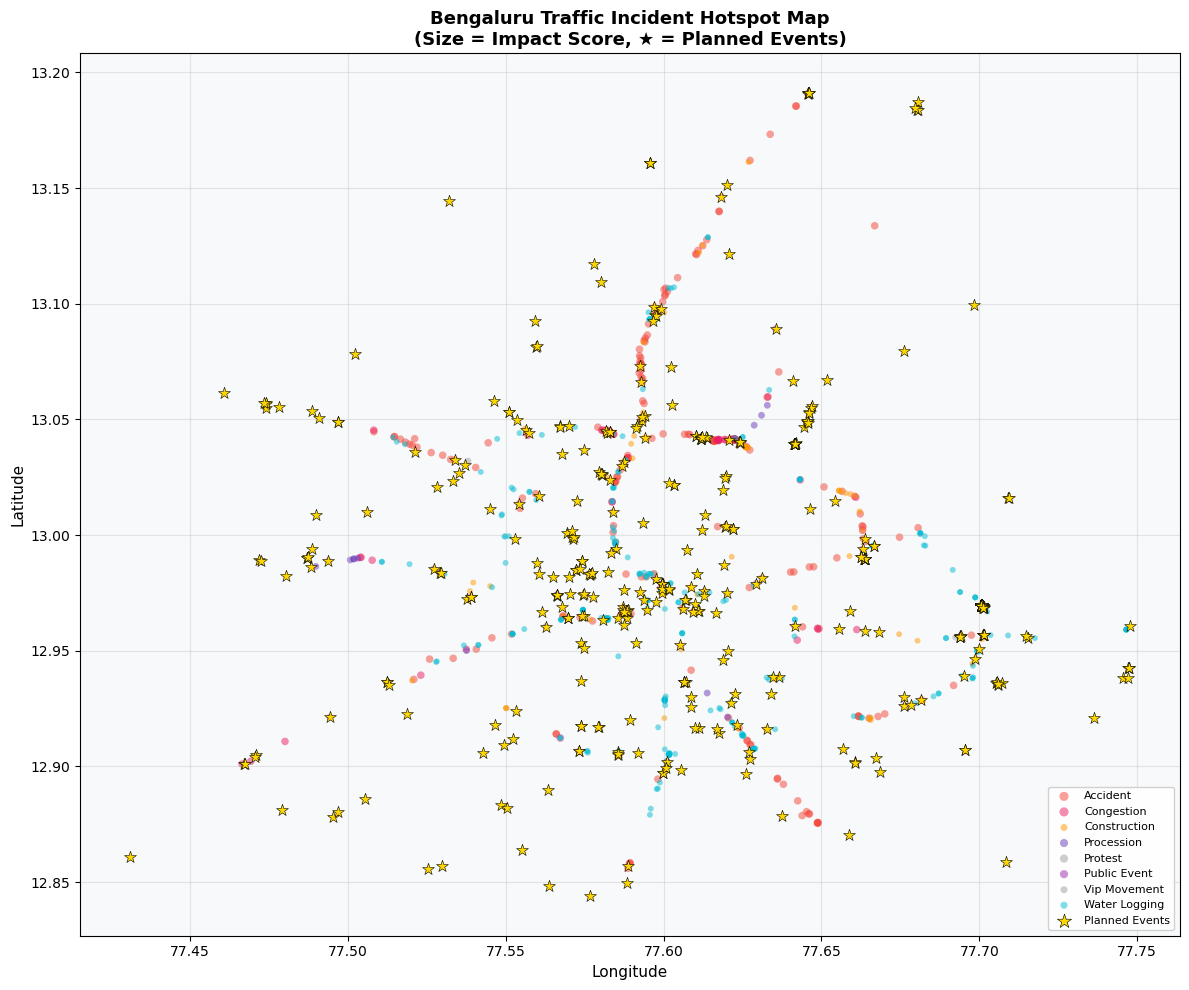

High-impact incidents plotted: 913


In [14]:
#Hotspot map
high_impact = df[(df['impact_score'] >= 6) &
                 df['latitude'].notna() & df['longitude'].notna() &
                 (df['latitude'] > 12.7) & (df['latitude'] < 13.2) &
                 (df['longitude'] > 77.4) & (df['longitude'] < 77.8)].copy()

fig, ax = plt.subplots(figsize=(12, 10))

cause_colors_map = {
    'accident'        : '#f44336',
    'congestion'      : '#e91e63',
    'public_event'    : '#9c27b0',
    'procession'      : '#673ab7',
    'construction'    : '#ff9800',
    'vehicle_breakdown': '#2196f3',
    'water_logging'   : '#00bcd4',
    'others'          : '#9e9e9e',
}

for cause, grp in high_impact.groupby('event_cause'):
    color = cause_colors_map.get(cause, '#9e9e9e')
    ax.scatter(grp['longitude'], grp['latitude'],
               c=color, s=grp['impact_score'] * 3,
               alpha=0.5, label=cause.replace('_',' ').title(), edgecolors='none')

#planned event locations
pe = df[(df['event_type']=='planned') & df['latitude'].notna() &
        (df['latitude'] > 12.7) & (df['latitude'] < 13.2) &
        (df['longitude'] > 77.4) & (df['longitude'] < 77.8)]
ax.scatter(pe['longitude'], pe['latitude'],
           c='gold', s=80, marker='*', zorder=5, label='Planned Events', edgecolors='black', linewidths=0.4)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Bengaluru Traffic Incident Hotspot Map\n(Size = Impact Score, ★ = Planned Events)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, markerscale=1.2, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('hotspot_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'High-impact incidents plotted: {len(high_impact)}')

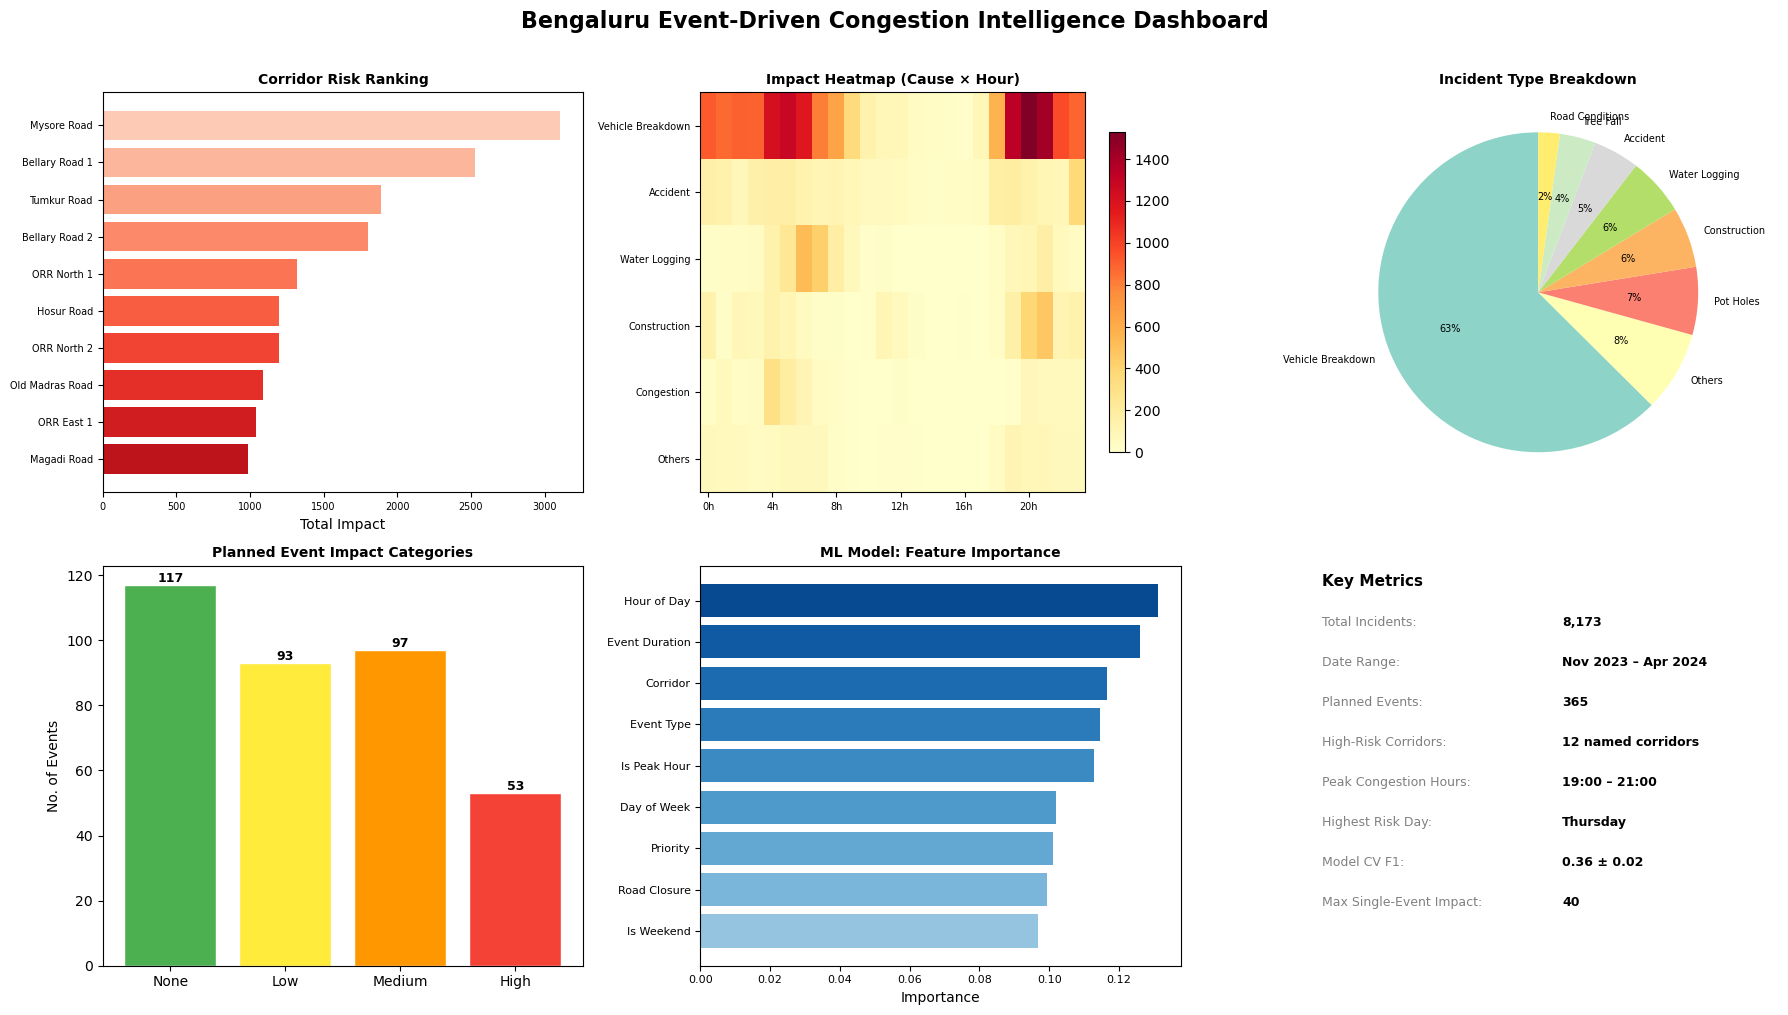

Dashboard saved.


In [15]:
#Feature importance
ax5 = fig.add_subplot(2, 3, 5)

FEATURE_LABELS = {
    'cause_enc'    : 'Event Type',
    'corridor_enc' : 'Corridor',
    'hour'         : 'Hour of Day',
    'day_enc'      : 'Day of Week',
    'priority_enc' : 'Priority',
    'closure_enc'  : 'Road Closure',
    'is_peak_hour' : 'Is Peak Hour',
    'is_weekend'   : 'Is Weekend',
    'duration_hrs' : 'Event Duration'
}

fi_plot = feat_imp.rename(FEATURE_LABELS)
ax5.barh(fi_plot.index[::-1], fi_plot.values[::-1],
         color=plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_plot))))
ax5.set_title('ML Model: Feature Importance', fontweight='bold', fontsize=10)
ax5.set_xlabel('Importance')
ax5.tick_params(labelsize=8)

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Bengaluru Event-Driven Congestion Intelligence Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

#Top corridors
ax1 = fig.add_subplot(2, 3, 1)
top10 = named_corridors.head(10)
ax1.barh(top10['corridor'][::-1], top10['total_impact'][::-1],
         color=plt.cm.Reds_r(np.linspace(0.2, 0.8, 10)))
ax1.set_title('Corridor Risk Ranking', fontweight='bold', fontsize=10)
ax1.set_xlabel('Total Impact')
ax1.tick_params(labelsize=7)

#Hourly heatmap
ax2 = fig.add_subplot(2, 3, 2)
hourly_cause = df.pivot_table(values='impact_score', index='event_cause',
                               columns='hour', aggfunc='sum', fill_value=0)
top_causes = hourly_cause.sum(axis=1).nlargest(6).index
subset = hourly_cause.loc[top_causes]
im = ax2.imshow(subset.values, aspect='auto', cmap='YlOrRd')
ax2.set_yticks(range(len(top_causes)))
ax2.set_yticklabels([c.replace('_',' ').title() for c in top_causes], fontsize=7)
ax2.set_xticks(range(0, 24, 4))
ax2.set_xticklabels([f'{h}h' for h in range(0, 24, 4)], fontsize=7)
ax2.set_title('Impact Heatmap (Cause × Hour)', fontweight='bold', fontsize=10)
plt.colorbar(im, ax=ax2, shrink=0.8)

#Event cause distribution
ax3 = fig.add_subplot(2, 3, 3)
top_causes_count = df['event_cause'].value_counts().head(8)
ax3.pie(top_causes_count.values,
        labels=[c.replace('_',' ').title() for c in top_causes_count.index],
        autopct='%1.0f%%', startangle=90,
        colors=plt.cm.Set3(np.linspace(0, 1, 8)),
        textprops={'fontsize': 7})
ax3.set_title('Incident Type Breakdown', fontweight='bold', fontsize=10)

# 4. Impact category distribution
ax4 = fig.add_subplot(2, 3, 4)
cat_data = impact_df['impact_category'].value_counts().reindex(['None','Low','Medium','High'])
bars = ax4.bar(cat_data.index, cat_data.values,
               color=['#4caf50','#ffeb3b','#ff9800','#f44336'], edgecolor='white')
for bar, val in zip(bars, cat_data.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=9, fontweight='bold')
ax4.set_title('Planned Event Impact Categories', fontweight='bold', fontsize=10)
ax4.set_ylabel('No. of Events')

#Feature importance
ax5 = fig.add_subplot(2, 3, 5)
fi_plot = feat_imp.rename(FEATURE_LABELS)
ax5.barh(fi_plot.index[::-1], fi_plot.values[::-1],
         color=plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_plot))))
ax5.set_title('ML Model: Feature Importance', fontweight='bold', fontsize=10)
ax5.set_xlabel('Importance')
ax5.tick_params(labelsize=8)

#key metrices
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
metrics = [
    ('Total Incidents', f'{len(df):,}'),
    ('Date Range', 'Nov 2023 – Apr 2024'),
    ('Planned Events', f'{len(planned):,}'),
    ('High-Risk Corridors', '12 named corridors'),
    ('Peak Congestion Hours', '19:00 – 21:00'),
    ('Highest Risk Day', 'Thursday'),
    ('Model CV F1', f'{xgb_scores.mean():.2f} ± {xgb_scores.std():.2f}'),
    ('Max Single-Event Impact', f'{impact_df["total_impact"].max():.0f}'),
]
y_pos = 0.95
ax6.text(0.05, y_pos, 'Key Metrics', fontsize=11, fontweight='bold', transform=ax6.transAxes)
for label, val in metrics:
    y_pos -= 0.10
    ax6.text(0.05, y_pos, f'{label}:', fontsize=9, color='gray', transform=ax6.transAxes)
    ax6.text(0.55, y_pos, val, fontsize=9, fontweight='bold', transform=ax6.transAxes)
ax6.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

In [16]:
import pickle
with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'xgb_model': xgb_model,
        'le_cause': le_cause,
        'le_corridor': le_corridor,
        'le_day': le_day,
        'le_priority': le_priority,
        'le_closure': le_closure,
        'le_target': le_target
    }, f)